In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import copy

In [12]:
import sys
data_path = '../data/github/'
sys.path.append('../codes/')
%run ../codes/data_input.py
%run ../codes/mcmc_fun_06.py
%run ../codes/SEIVR.py

In [13]:
### 0 and 15 start from 18 April 2020 till 07 Nov 2020
## target
###
death_06_wk = np.loadtxt('deaths_06_phase2_v3.csv', delimiter=',')#deaths_06_phase2.csv
## start from 4 Jan 2020
death_06_wk_s = death_06_wk[12:,:] 
### the no zero start with 21 March 2020 ## index for that week is 11?
### for the phase 2, the start is 28 March 2020, index is 12
delay_init = (14, 2)
delay_dist_init = delay_dist(delay_init[0],delay_init[1],21)
####
n_races = 5 ## all is another race
n_states = 7
n_wk_in_wd = 4
T = 28*8+14+14 #(54+2)*7 #7*n_wk_window+14
print(T)
IFR_06_daily_wd = np.zeros((T,5))
IFR_06_daily_wd_phase1 = np.loadtxt('my_ifr_ts-v6_06.csv')
end_idx = T #IFR_06_daily_wd_phase1.shape[0] - 14
IFR_06_daily_wd[:end_idx,:] = IFR_06_daily_wd_phase1[:end_idx,:]
IFR_06_daily_wd[end_idx:] = IFR_06_daily_wd_phase1[end_idx-1]
M_eta_06 = np.loadtxt('M_eta_06_v2.csv')

252


In [14]:
###
beta_base_06 = np.zeros((T,5))
beta_base_06[:,:] = 1
real_wk_idx = 0
n_mcmc = 12000
n_windows = 14 #14 for cheating and phase 2 and 9 for tasking
# upper_limit_0 = np.array([0.75, 0.75, 0.75, 0.75,1])
# upper_limit = np.array([0.1, 0.5, 0.5, 0.5, 0.5])
factor_initials = np.array([0.2, 0.3 , 0.2, 0.4, 0.2])
seed_initials = np.array([10, 2,  0, 2,  0])
seed_limit = np.array([400, 400,  400, 400,  100])
M_trace = np.zeros((n_mcmc,1+n_windows,5))  #9
## 9 month is the parameter numbers + 1 seed
M_trace[0,0,:] = seed_initials
M_trace[0,1:,:] = factor_initials
### next months initial values is the last month's final values

In [15]:
for mcmc_iter in range(n_mcmc-1):
    if mcmc_iter%200 == 0:
        print(mcmc_iter)
    seed_temp = copy.deepcopy(M_trace[mcmc_iter,0,:])
    upper_seed_tobe = seed_temp+10
    lower_seed_tobe = seed_temp-10
    lower_seed_tobe[lower_seed_tobe<0] = 0
    
    upper_seed_tobe = np.minimum(upper_seed_tobe, 400)## specify the limits
    lower_seed_tobe = np.minimum(lower_seed_tobe, 400)##
    
    step_ls = [1, 1, 1, 1, 1]
    proposed_seed_distributions = [np.arange(lower, upper + step, step) for step, lower, upper in zip(step_ls, lower_seed_tobe, upper_seed_tobe)] 

    State = np.zeros((T, n_states, n_races))
    statestart = getStart(seed=seed_temp, factor=3, N_all=global_N_06)
    State[0] = statestart ## time 0, there are 7 states
    state_check = copy.deepcopy(State)
    
    factor_temp = copy.deepcopy(M_trace[mcmc_iter,1:,:])
    beta_t_check = np.repeat(factor_temp, 7*n_wk_in_wd, axis=0) ### already take out the only beta part!
    # 7 is 7month from march
    L_death_base, _, _, _  = para_LKH(state_check,beta_t_check,M_eta_06, IFR_06_daily_wd, delay_dist_init, real_wk_idx,T,death_06_wk_s,6) 
    for par_idx in range(5):
        para_r_0 = seed_temp[par_idx]
        seed_gen_dis_r = proposed_seed_distributions[par_idx]
        para_iter_r = np.random.choice(seed_gen_dis_r)
        seed_temp[par_idx] = para_iter_r
        
        state_temp = copy.deepcopy(State)
        statestart = getStart(seed=seed_temp, factor=3, N_all=global_N_06)
        state_temp[0] = statestart
        state_check = copy.deepcopy(state_temp)
        beta_t_check = np.repeat(factor_temp, 7*n_wk_in_wd, axis=0) 

        L_death_iter, flag, _, _ = para_LKH(state_check, beta_t_check, M_eta_06, IFR_06_daily_wd, delay_dist_init, real_wk_idx, T, death_06_wk_s,6) 
        if flag == 1:
            M_trace[mcmc_iter,0,:] = 0
            seed_temp[par_idx] = para_r_0
            state_temp = copy.deepcopy(State)
            break
        else:
            u = L_death_iter-L_death_base
            if u>0 or u>np.log(np.random.rand()):
                L_death_base = L_death_iter
                para_post = para_iter_r
            else:
                para_post = para_r_0
                state_temp = copy.deepcopy(State)
        seed_temp[par_idx] = para_post
        state_check = state_temp
        M_trace[mcmc_iter+1,0,par_idx] = para_post
    
    for p_idx in range(n_races*n_windows):
        race_idx = p_idx%5
        window_idx = p_idx//5
        # print(window_idx)
        factor_i = factor_temp[window_idx,race_idx]
        upper_factor_tobe_p = factor_i+factor_i*0.1
        lower_factor_tobe_p = factor_i-factor_i*0.1

        upper_factor_tobe = np.minimum(upper_factor_tobe_p, 1)
        lower_factor_tobe = np.minimum(lower_factor_tobe_p, 1)
        ### specify the upper limits
       
        proposed_factor_distributions = np.arange(lower_factor_tobe, upper_factor_tobe+0.001, 0.001)

        para_r_0 = factor_i
        factor_gen_dis_r = proposed_factor_distributions
        para_iter_r = np.random.choice(factor_gen_dis_r)
        factor_temp[window_idx,race_idx] = para_iter_r

        # state_check = copy.deepcopy(State)
        beta_t_check =  np.repeat(factor_temp, 7*4, axis=0) 
        L_death_iter, flag, _, _ = para_LKH(state_check, beta_t_check, M_eta_06,IFR_06_daily_wd, delay_dist_init, real_wk_idx, T, death_06_wk_s,6) 
        if flag == 1:
            M_trace[mcmc_iter,window_idx,:] = 0
            factor_temp[window_idx,race_idx] = para_r_0
            break
        else:
            u = L_death_iter-L_death_base
            if u>0 or u>np.log(np.random.rand()):
                L_death_base = L_death_iter
                para_post = para_iter_r
            else:
                para_post = para_r_0
            factor_temp[window_idx,race_idx] = para_post
            M_trace[mcmc_iter+1,window_idx+1,race_idx] = para_post 
            #### M_trace is 1 dimension more than factor_temp on axis==1

### the acceptance rate

0
200
400
600
800
1000
1200
1400
1600
1800
2000
2200
2400
2600
2800
3000
3200
3400
3600
3800
4000
4200
4400
4600
4800
5000
5200
5400
5600
5800
6000
6200
6400
6600
6800
7000
7200
7400
7600
7800
8000
8200
8400
8600
8800
9000
9200
9400
9600
9800
10000
10200
10400
10600
10800
11000
11200
11400
11600
11800


In [20]:
np.save('M_trace_06_phase1', M_trace)
# M_trace = np.load('M_trace_06_phase1_temp.npy')

In [5]:
M_trace.shape

(2000, 15, 5)

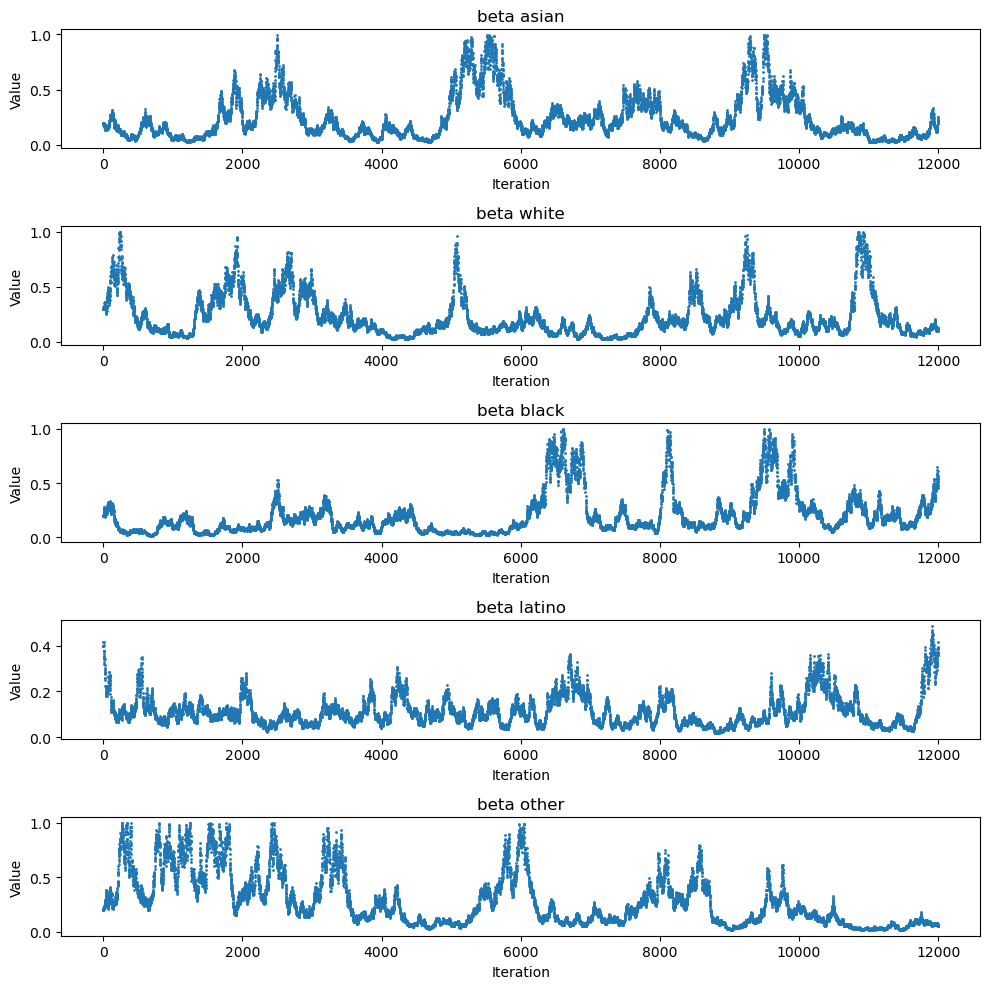

In [16]:
num_parameters = 5
n_mcmc = M_trace.shape[0]
# Creating trace plots for each parameter
fig, axs = plt.subplots(num_parameters, 1, figsize=(10, 2 * num_parameters))

for i in range(num_parameters):
    # fit_idx = i//5
    r_idx = i%5
    r = race_list_06[r_idx]
    # print(i, r_idx, fit_idx)
    axs[i].scatter(range(n_mcmc),M_trace[:n_mcmc,10,r_idx],s=1)

    axs[i].set_title(f'beta {r}')

    axs[i].set_xlabel('Iteration')
    axs[i].set_ylabel('Value')


plt.tight_layout()
plt.show()

In [7]:
M_trace.shape

(12000, 15, 5)

In [17]:
# M_trace = M_trace[:10000,:,:]
# n_mcmc = 2000
burn_in = 10000#10000
step = 10
thin = int((n_mcmc - burn_in)/step)
# thin = 200
n_windows = 9 #9 #14
M_death_wk = np.zeros((thin,n_windows*4-2,5))
M_State = np.zeros((thin,n_windows*28,7,5))
M_beta = np.zeros((thin,n_windows*28,5))
M_trace_steady = M_trace[[-(n_mcmc - burn_in)+step*k1+1 for k1 in range(thin)]]
# M_trace_steady = M_trace[[4000 + step*k1+1 for k1 in range(thin)]]
for s_i in range(thin):
    seed_post_i = M_trace_steady[s_i,0,:]        
    State = np.zeros((T, n_states, n_races))
    statestart = getStart(seed=seed_post_i, factor=3, N_all=global_N_06)
    State[0] = statestart
    state_check = State
    factor_post_i = M_trace_steady[s_i,1:n_windows+1,:]
    beta_t_check = np.repeat(factor_post_i,28, axis=0)
    M_beta[s_i,:,:] = beta_t_check
    _, _, death_wk, state_alltime = para_LKH(state_check,beta_t_check,M_eta_06,IFR_06_daily_wd, delay_dist_init, 0,T, death_06_wk_s,6)
    M_death_wk[s_i,:,:] = death_wk
    M_State[s_i,:,:,:] = state_alltime[:,:,:]

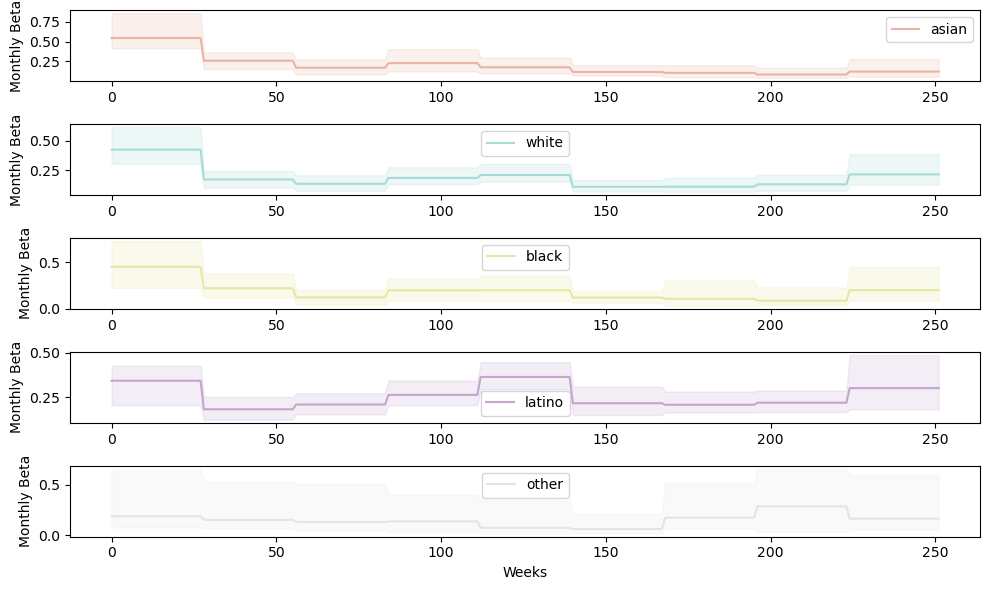

In [18]:
# Create a single figure and axes
M_beta_cheat = np.zeros((T,5))
fig, axs = plt.subplots(5, 1, figsize=(10, 6))
for race_idx in range(5):
    ax = axs[race_idx]
    r = race_list_06[race_idx]
    beta_r = np.median(M_beta[:,:,race_idx],axis=0)
    M_beta_cheat[:,race_idx] = beta_r
    beta_r_l = np.quantile(M_beta[:,:,race_idx],0.025,axis=0)
    beta_r_u = np.quantile(M_beta[:,:,race_idx],0.975,axis=0)
    ax.plot(range(28*n_windows), beta_r, label=r,c = custom_colors[r])
    ax.fill_between(range(28*n_windows), beta_r_l, beta_r_u, alpha=0.2, color=custom_colors[r])
    ax.set_ylabel('Monthly Beta')
    ax.legend()
plt.xlabel('Weeks')
plt.tight_layout()
plt.show()

In [36]:
M_beta.shape

(200, 392, 5)

In [13]:
# np.savetxt('beta_r_cheating.csv',M_beta_cheat)
np.savetxt('beta_06_phase2_A.csv',M_beta.reshape(-1, 5))

In [11]:
M_death_wk.shape

(200, 34, 5)

asian
white
black
latino
other


Text(0.5, 0, 'Weeks')

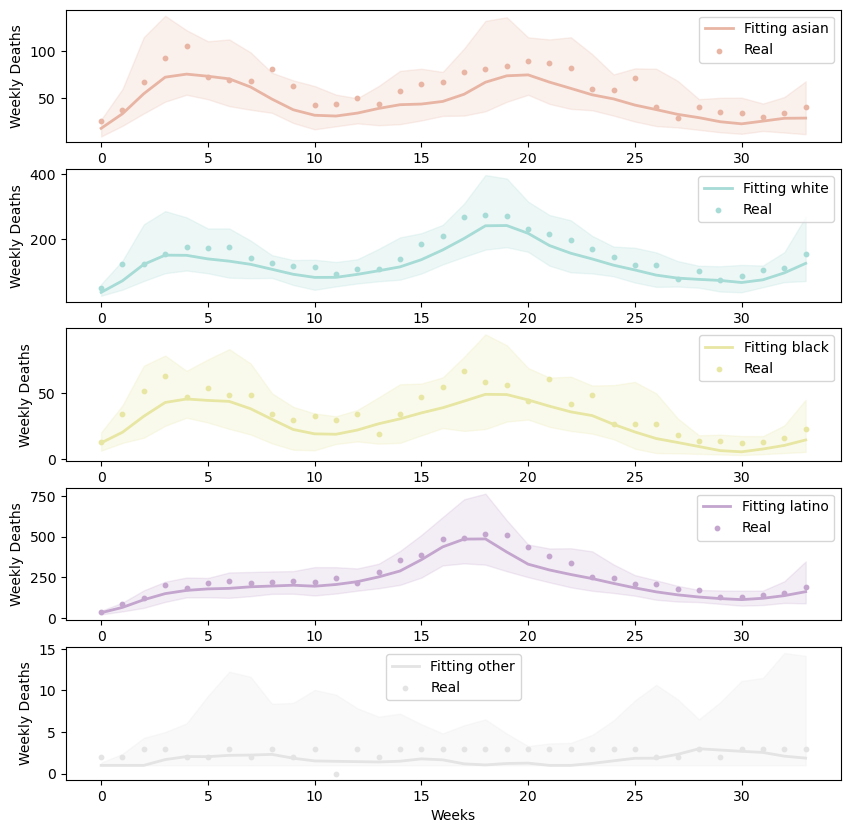

In [19]:
fig, axs = plt.subplots(5, 1, figsize=(10, 10))
for r_idx in range(5):
    r = race_list_06[r_idx]
    print(r)
    ax = axs[r_idx]
    death_r = np.median(M_death_wk[:,:,r_idx],axis=0)
    death_r_l = np.quantile(M_death_wk[:,:,r_idx],0.025,axis=0)
    death_r_u = np.quantile(M_death_wk[:,:,r_idx],0.975,axis=0)
    ## 34 54
    ax.plot(range(34), death_r, label=f"Fitting {r}",c = custom_colors[r], lw=2)
    ax.fill_between(range(34), death_r_l, death_r_u, alpha=0.2, color=custom_colors[r])
    # for s_i in range(thin):
    #     plt.plot(M_death_wk[s_i,:,r_idx], '-', c=custom_colors[r], alpha=0.1, lw=1)
        # new_death_wk = Reshape_WK(new_death_month[s_i],7,34)
        # plt.plot(new_death_wk[:,r_idx], '-', c=custom_colors[r], alpha=0.1, lw=1)
        # plt.plot(ts_death_wk[s_i,:36,r_idx], '-', c=custom_colors[r], alpha=0.1, lw=1) #
    ax.scatter(range(34), death_06_wk_s[:34,r_idx], c=custom_colors[r], s=10, label="Real")
    # plt.plot(death_wk[:,r_idx], 'o', label=f"Simulated: {r}", c=custom_colors[r])
    ax.set_ylabel('Weekly Deaths')
    ax.legend()
plt.xlabel('Weeks')

In [28]:
# M_trace = np.load('M_trace_06.npy')

In [11]:
IFR_06_daily_wd_adj = np.loadtxt('my_ifr_ts-v6_06_adj.csv',delimiter=',')

In [12]:
%run ../codes/phase2.py

In [13]:
_, M_death_wk_ifr_adj, M_State_ifr = simulate_scenario(thin, n_windows, T,n_states, n_races, global_N_06,M_trace_steady, M_eta_06, IFR_06_daily_wd_adj, delay_dist_init, death_06_wk_s,6,M_beta_adj=None)

death_r_ifr = np.median(M_death_wk_ifr_adj[:,:],axis=0)
death_r_l_ifr = np.quantile(M_death_wk_ifr_adj[:,:],0.05,axis=0)
death_r_u_ifr = np.quantile(M_death_wk_ifr_adj[:,:],0.95,axis=0)

In [14]:
M_beta_adj = np.loadtxt('beta_06_phase2_A_adj.csv').reshape(200, 392, 5)

In [15]:
_, M_death_wk_beta_adj, M_State_beta = simulate_scenario(thin, n_windows, T,n_states, n_races, global_N_06, M_trace_steady, M_eta_06, IFR_06_daily_wd, delay_dist_init, death_06_wk_s,6,M_beta_adj=M_beta_adj)

death_r_beta = np.median(M_death_wk_beta_adj[:,:],axis=0)
death_r_l_beta = np.quantile(M_death_wk_beta_adj[:,:],0.05,axis=0)
death_r_u_beta = np.quantile(M_death_wk_beta_adj[:,:],0.95,axis=0)

In [16]:
_, M_death_wk_all_adj, M_State_all = simulate_scenario(thin, n_windows, T,n_states, n_races, global_N_06, M_trace_steady, M_eta_06, IFR_06_daily_wd_adj, delay_dist_init, death_06_wk_s,6,M_beta_adj=M_beta_adj)

death_r_all = np.median(M_death_wk_all_adj[:,:],axis=0)
death_r_l_all = np.quantile(M_death_wk_all_adj[:,:],0.05,axis=0)
death_r_u_all = np.quantile(M_death_wk_all_adj[:,:],0.95,axis=0)

asian
white
black
latino
other


Text(0.5, 0, 'Weeks')

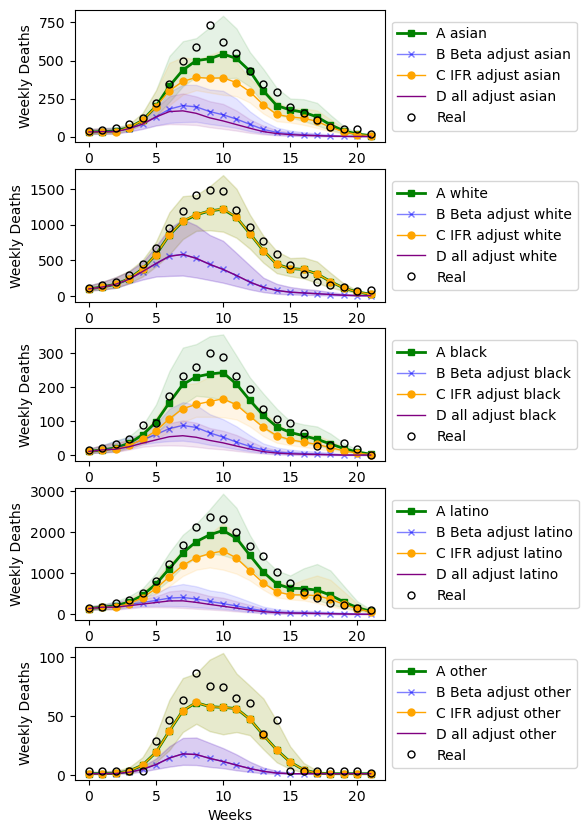

In [17]:
fig, axs = plt.subplots(5, 1, figsize=(4, 10))
for r_idx in range(5):
    r = race_list_06[r_idx]
    print(r)
    ax = axs[r_idx]
    death_r = np.median(M_death_wk[:,:,r_idx],axis=0)
    death_r_l = np.quantile(M_death_wk[:,:,r_idx],0.05,axis=0)
    death_r_u = np.quantile(M_death_wk[:,:,r_idx],0.95,axis=0)

    ## 34 54
    ax.plot(range(22), death_r[-22:], 's-',label=f"A {r}",c = 'green', lw=2,ms=5)
    ax.fill_between(range(22), death_r_l[-22:], death_r_u[-22:], alpha=0.1, color='green')

    ax.plot(range(22), death_r_beta[-22:,r_idx], 'x-',label=f"B Beta adjust {r}",c = 'blue', lw=1,alpha=0.5,ms=5)
    ax.fill_between(range(22), death_r_l_beta[-22:,r_idx], death_r_u_beta[-22:,r_idx], alpha=0.1, color='blue')
    
    ax.plot(range(22), death_r_ifr[-22:,r_idx], 'o-',label=f"C IFR adjust {r}",c = 'orange', lw=1,ms=5)
    ax.fill_between(range(22), death_r_l_ifr[-22:,r_idx], death_r_u_ifr[-22:,r_idx], alpha=0.1, color= 'orange')

    ax.plot(range(22), death_r_all[-22:,r_idx], label=f"D all adjust {r}",c = 'purple', lw=1)
    ax.fill_between(range(22), death_r_l_all[-22:,r_idx], death_r_u_all[-22:,r_idx], alpha=0.1, color= 'purple')
    
    ax.plot(range(22), death_06_wk_s[-22:,r_idx], ls = 'None', c='black', marker = 'o', label="Real",mfc='none',ms=5)
    # plt.plot(death_wk[:,r_idx], 'o', label=f"Simulated: {r}", c=custom_colors[r])
    ax.set_ylabel('Weekly Deaths')
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.xlabel('Weeks')

In [18]:
M_death_out = np.zeros((4,thin, 20, 6))
M_death_out[0,:,:,:5] = M_death_wk[:,-20:,:] ## A
M_death_out[0,:,:,5] = np.sum(M_death_wk[:,-20:,:],axis=2) ## A

M_death_out[1,:,:,:5] = M_death_wk_beta_adj[:,-20:,:] ## B
M_death_out[1,:,:,5] = np.sum(M_death_wk_beta_adj[:,-20:,:],axis=2) ## 

M_death_out[2,:,:,:5] = M_death_wk_ifr_adj[:,-20:,:] ## C
M_death_out[2,:,:,5] = np.sum(M_death_wk_ifr_adj[:,-20:,:],axis=2) ## C

M_death_out[3,:,:,:5] = M_death_wk_all_adj[:,-20:,:] ## D
M_death_out[3,:,:,5] = np.sum(M_death_wk_all_adj[:,-20:,:],axis=2) ## D

In [19]:
scenaria_ls = ['A-2020-11-15','B-2020-11-15','C-2020-11-15','D-2020-11-15']

In [20]:
column_names = ['origin_date', 'scenario_id', 'target','horizon','location','race_ethnicity','output_type','output_type_id','value','run_grouping','stochastic_run']
df_all_out = pd.DataFrame(columns=column_names)
for s_idx, s_name in enumerate(scenaria_ls):
    print(s_idx,s_name)
    for r_idx in range(6):
        if r_idx < 5:
            r = race_list_06[r_idx]
        else:
            r = 'overall'
        for run_i in range(200):
            m_death_wk_i_r = M_death_out[s_idx,run_i,:,r_idx]
            df_i_r = pd.DataFrame(m_death_wk_i_r, columns=['value'])
            df_i_r['origin_date'] = '2020-11-15'
            df_i_r['scenario_id'] = s_name
            df_i_r['target'] = 'inc death'
            df_i_r['location'] = str('06')
            df_i_r['stochastic_run'] = 1 ### If each model run is not stochastic, the column will be set to a unique identifier: 1 for all rows
            df_i_r['horizon'] = np.arange(1,20+1)
            df_i_r['race_ethnicity'] = r
            df_i_r['output_type'] = 'sample'
            df_i_r['output_type_id'] = 'NA'
            df_i_r['run_grouping'] = run_i+1
            df_i_r['stochastic_run'] = 1
            df_all_out = pd.concat([df_all_out,df_i_r],ignore_index=True)

0 A-2020-11-15


/var/folders/_0/2l3z2qss74scb88wvbv1szxr0000gn/T/ipykernel_38852/29072669.py:24: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_all_out = pd.concat([df_all_out,df_i_r],ignore_index=True)


1 B-2020-11-15
2 C-2020-11-15
3 D-2020-11-15


In [21]:
def get_infected(M_State):
    new_case = np.zeros((200,56*7,n_races))
    M_inf_wk = np.zeros((200,54,n_races))
    new_case[:,0,:] = M_State[:,0,1,:]/parameters['Z'] + M_State[:,0,5,:]/parameters['Z']
    shift_t = len(delay_dist_init)
    print(shift_t)
    for i in range(200):
        new_case_t = new_case[i]
        for t in range(1, 56*7):
            deltacase = M_State[i,t,1,:]/parameters['Z'] + M_State[i,t,5,:]/parameters['Z']
            deltacase = deltacase.reshape(1, n_races)
            prob_case = delay_dist_init.dot(deltacase) ## delay to observe
            new_case_t[t:min(t+shift_t,56*7)] += prob_case[:min(56*7-t,shift_t)]
            new_case[i] = new_case_t
        M_inf_wk[i] = Reshape_WK(new_case[i],21,54,6)
    return M_inf_wk

In [22]:
M_inf_wk = get_infected(M_State)
M_inf_wk_beta = get_infected(M_State_beta)
M_inf_wk_ifr = get_infected(M_State_ifr)
M_inf_wk_all = get_infected(M_State_all)

21
21
21
21


In [23]:
M_inf_out = np.zeros((4,thin, 20, 6))
M_inf_out[0,:,:,:5] = M_inf_wk[:,-20:,:] ## A
M_inf_out[0,:,:,5] = np.sum(M_inf_wk[:,-20:,:],axis=2) ## A

M_inf_out[1,:,:,:5] = M_inf_wk_beta[:,-20:,:] ## B
M_inf_out[1,:,:,5] = np.sum(M_inf_wk_beta[:,-20:,:],axis=2) ## 

M_inf_out[2,:,:,:5] = M_inf_wk_ifr[:,-20:,:] ## C
M_inf_out[2,:,:,5] = np.sum(M_inf_wk_ifr[:,-20:,:],axis=2) ## C

M_inf_out[3,:,:,:5] = M_inf_wk_all[:,-20:,:] ## D
M_inf_out[3,:,:,5] = np.sum(M_inf_wk_all[:,-20:,:],axis=2) ## D

In [24]:
for s_idx, s_name in enumerate(scenaria_ls):
    print(s_idx,s_name)
    for r_idx in range(6):
        if r_idx < 5:
            r = race_list_06[r_idx]
        else:
            r = 'overall'
        for run_i in range(200):
            m_inf_wk_i_r = M_inf_out[s_idx,run_i,:,r_idx]
            df_i_r = pd.DataFrame(m_inf_wk_i_r, columns=['value'])
            df_i_r['origin_date'] = '2020-11-15'
            df_i_r['scenario_id'] = s_name
            df_i_r['target'] = 'inc inf'
            df_i_r['location'] = str('06')
            df_i_r['stochastic_run'] = 1 ### If each model run is not stochastic, the column will be set to a unique identifier: 1 for all rows
            df_i_r['horizon'] = np.arange(1,20+1)
            df_i_r['race_ethnicity'] = r
            df_i_r['output_type'] = 'sample'
            df_i_r['output_type_id'] = 'NA'
            df_i_r['run_grouping'] = run_i+1
            df_i_r['stochastic_run'] = 1
            df_all_out = pd.concat([df_all_out,df_i_r],ignore_index=True)

0 A-2020-11-15
1 B-2020-11-15
2 C-2020-11-15
3 D-2020-11-15


In [25]:
df_all_out.to_csv('output_06_phase2.csv',index=False)

In [35]:
df_all_out.head()

,origin_date,scenario_id,target,horizon,location,race_ethnicity,output_type,output_type_id,value,run_grouping,stochastic_run
0,2020-11-15,A-2020-11-15,inc death,1,06,asian,sample,NA,33.617807,1,1
1,2020-11-15,A-2020-11-15,inc death,2,06,asian,sample,NA,61.976159,1,1
2,2020-11-15,A-2020-11-15,inc death,3,06,asian,sample,NA,117.504194,1,1
3,2020-11-15,A-2020-11-15,inc death,4,06,asian,sample,NA,206.873930,1,1
4,2020-11-15,A-2020-11-15,inc death,5,06,asian,sample,NA,319.232133,1,1
